# Compare computational and experimental results
 - peak pressure
    - and location
 - contact area
    - raw outputs
    - FEA adjusted to experimental resolution 
        - % overlap as well
 - displacement
 ---
 - Could compare across force range(10, 50+10, 10)
---
#### Study1
 - check it goes to 150N
#### Study2
 - runs to F = range(10, 50+10, 10)
 - Be good to figure out user defined refinement

# Experimental

In [1]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import get_sensor_loc, parse_tekscan, F2P, build_sensor_mesh, project_sensor, project_sensor_new, project_sensor_complex
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

In [2]:
exp_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1')
raw_files = list(exp_path.glob('*-raw.asm'))
raw_files

[PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/10N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/50N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/30N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/40N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/20N-raw.asm')]

In [3]:
tek_data = {} # {F1: imgP1, ...}
for raw_file in raw_files:
    F = int(raw_file.name.split('-')[0].split('N')[0])
    img = parse_tekscan(raw_file, 1)[0]
    imgP = F2P(img, F)[0] # convert from raw to pressure values using known F

    tek_data[F] = imgP

# FEA

In [4]:
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_files = list(fea_path.glob('study2_*/**/*.inp'))
inp_files

[PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-00/35T-neutral-00.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-01/35T-neutral-01.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-04/35T-neutral-04.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-03/35T-neutral-03.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-02/35T-neutral-02.inp')]

In [49]:
step, frame = 0, -1
field_metrics = ["CPRESS", "U"]
history_metrics = ['CAREA', 'RF']

fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
for inp_file in inp_files:
    csv_dir = inp_file.parent / 'resultCSVs' 

    # get F
    run_id = inp_file.with_suffix('').name.split('-')[-1]
    param_path = fea_path / f'study2_35T4d5/params/loop_params/{run_id}.json'
    with open(param_path, 'r') as f:
        F = json.load(f)['_loop']['max_force']

    # get meshes
    meshes = inp2pv(inp_file)
    for bone, mesh in meshes.items():
        instance = f"{bone.upper()}_INST"
        
        # Field data
        for metric in field_metrics:
            field_path = get_field_path(csv_dir, metric, step, frame, instance)
            field_df = get_field_df(field_path)
            add_field_to_mesh(mesh, field_df)

        # History data
        history_data = pd.read_csv(get_history_path(csv_dir, step))
        # F
        RF_data = history_data[history_data['historyOutputKey']=='RF1']
        RF = np.abs(RF_data['value'].iloc[frame])
        # A
        CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
        CA = CAREA_data['value'].iloc[frame]

        mesh.field_data['RF'] = RF
        mesh.field_data['CA'] = CA

        #Summary data
        mesh.field_data['P_max'] = mesh['CPRESS'].max()
        mesh.field_data['P_avg'] = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
        mesh.field_data['loc_Pmax'] = np.array(mesh.points[np.argmax(mesh['CPRESS'])])

    fea_data[F] = meshes

# Compare
 - Do contact area overlap % and Pmax location at some point

## Raw FEA results

In [ ]:
def find_boundary_cells(a):
    """
    input: NxM array of cells
    Returns: NxM (1, 0) array of non-zero cells that border a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    CA_e_low = find_boundary_cells(img).sum() * sensel_area * 0.75 # lower bound error bar for CA
    CA_e_high = find_boundary_cells(img).sum() * sensel_area * 0.25 # upper bound error bar for CA
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e_low': CA_e_low,
        'CA_e_high': CA_e_high,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

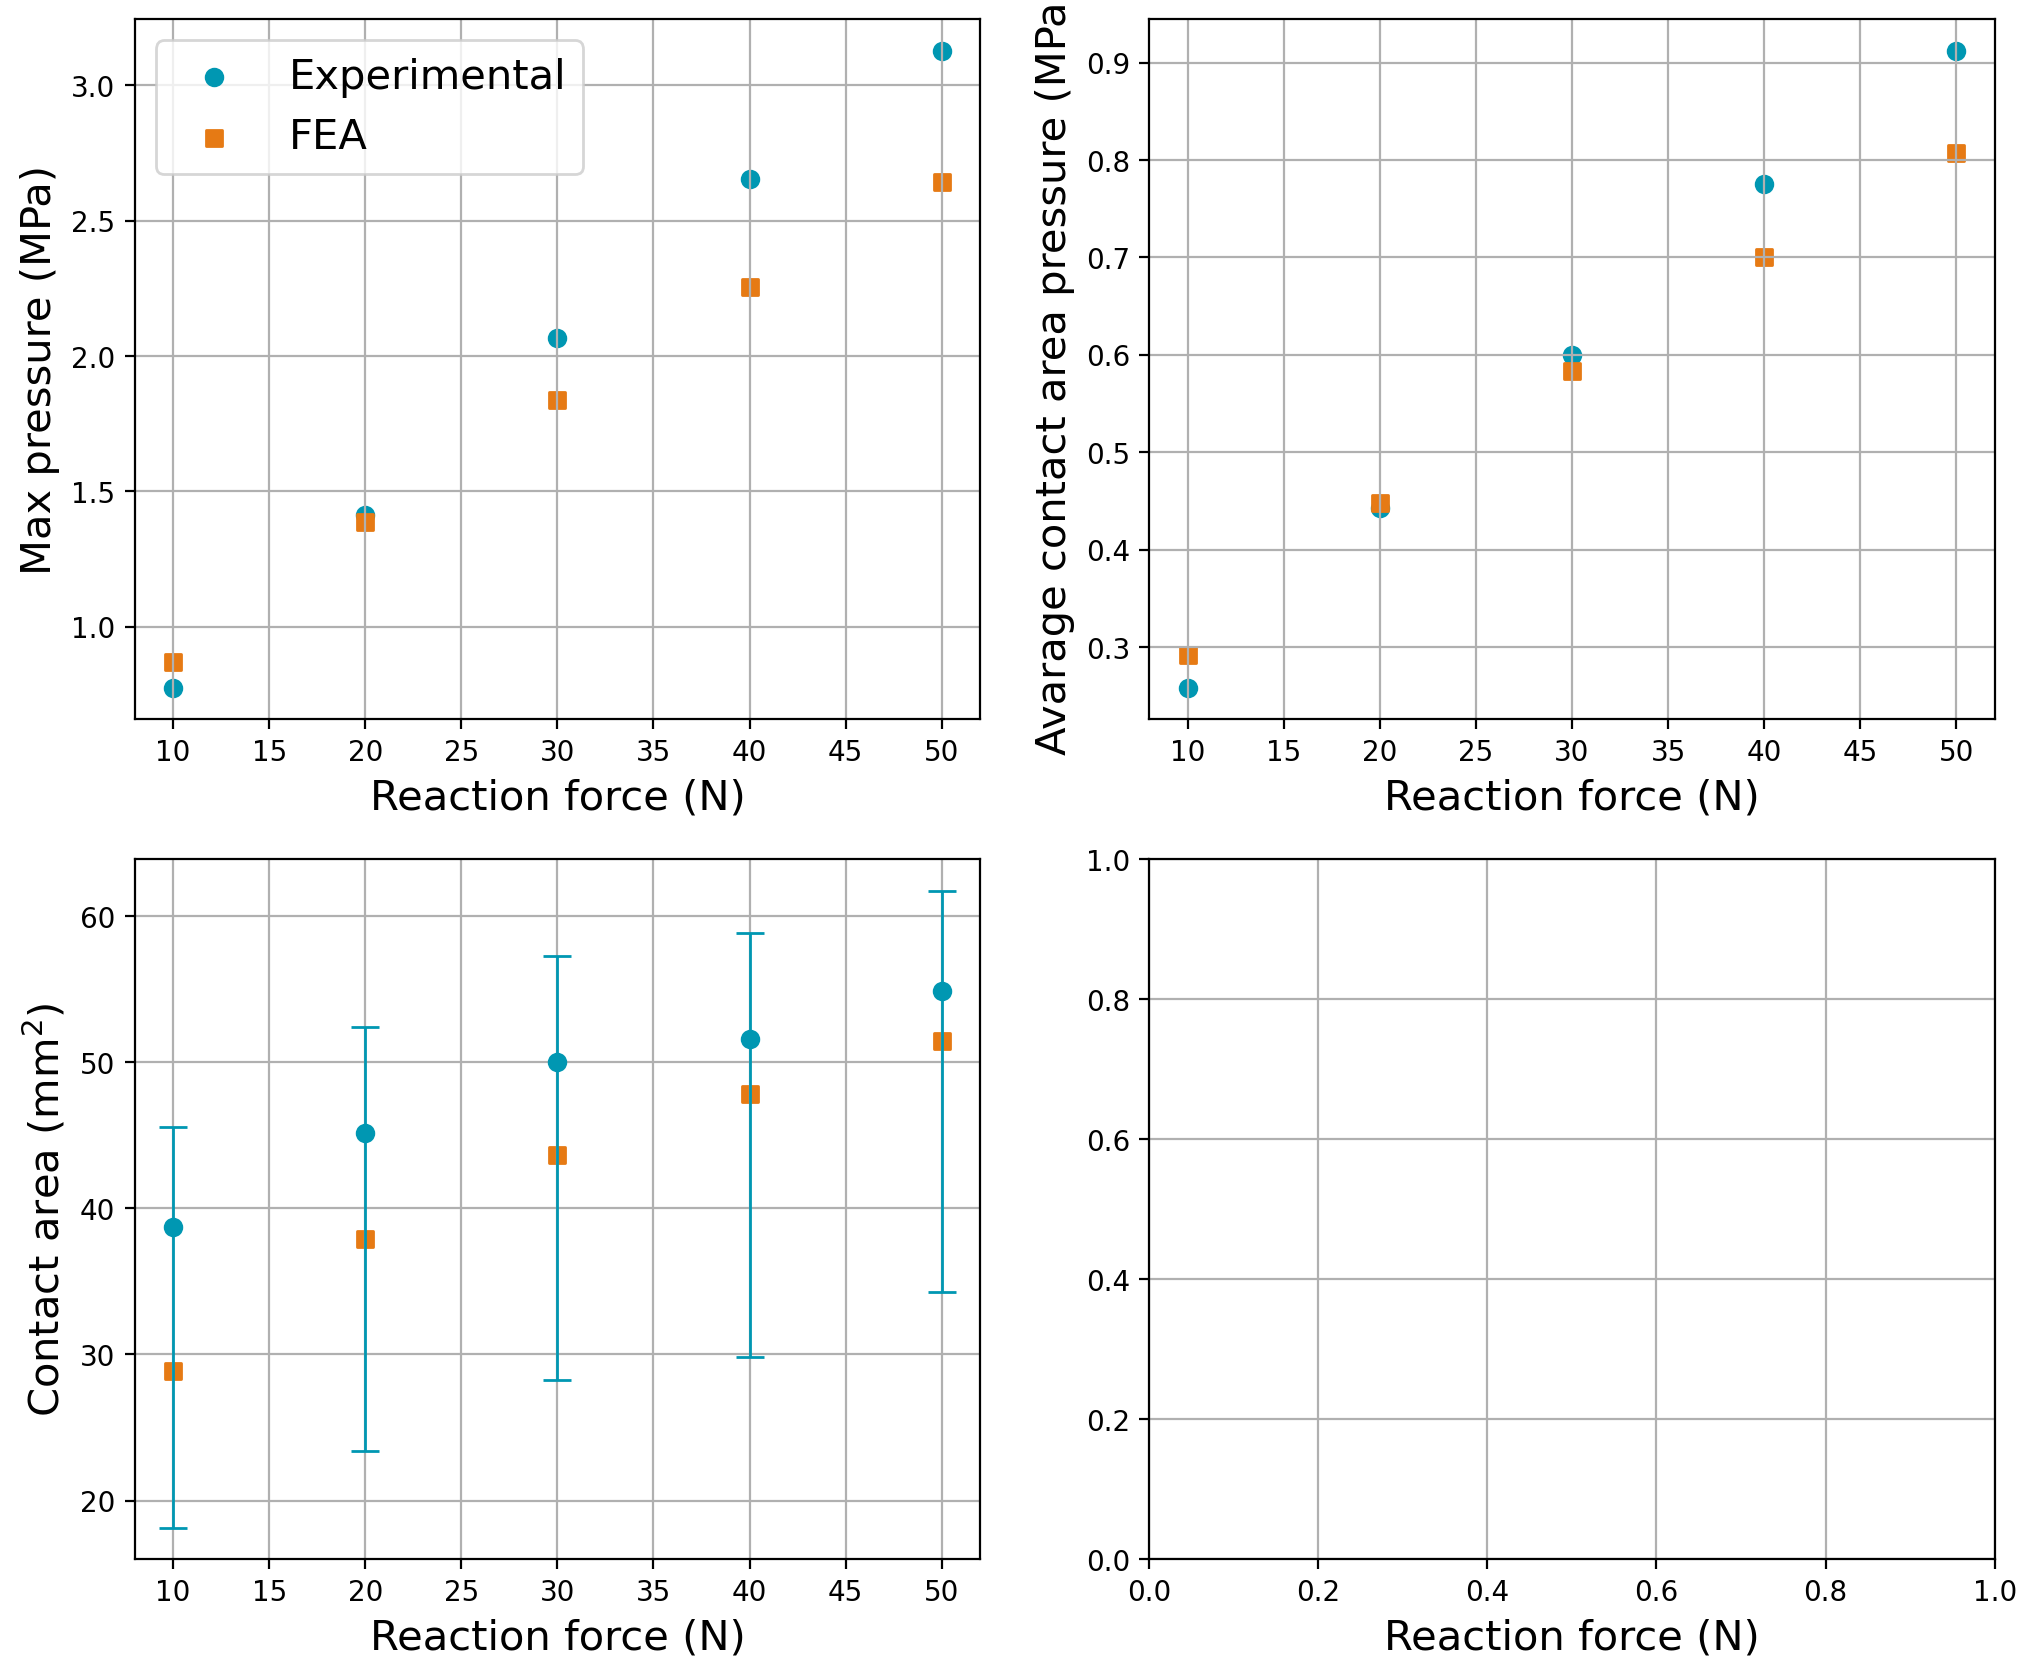

In [119]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 15
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fea": "#e67a14"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o",      # circle
    "fea": "s",    # square
}


Fs = sorted(tek_data.keys())
for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    mesh = fea_data[F]['tpm']

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FEA' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek)
    ax[0].scatter(F, mesh.field_data['P_max'], c=colors['fea'], marker=markers['fea'], label=label_fea)

    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'])
    ax[1].scatter(F, mesh.field_data['P_avg'], c=colors['fea'], marker=markers['fea'])

    ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=1)
    ax[2].scatter(F, mesh.field_data['CA'], c=colors['fea'], marker=markers['fea'])


ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Avarage contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
plt.show()

## FEA dowscaled to sensor grid

In [67]:
Fs = sorted(fea_data.keys())

fea_grid_data = {}
for F in Fs:
    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-1, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)

    fea_grid = project_sensor(fea_data[F]['tpm'].extract_surface(algorithm=None), sensor, tek_data[F], data_loc='cells', 
                                downscale_fea=True, return_fea_grid=True, downscale_mode='max')
    
    fea_grid_data[F] = fea_grid

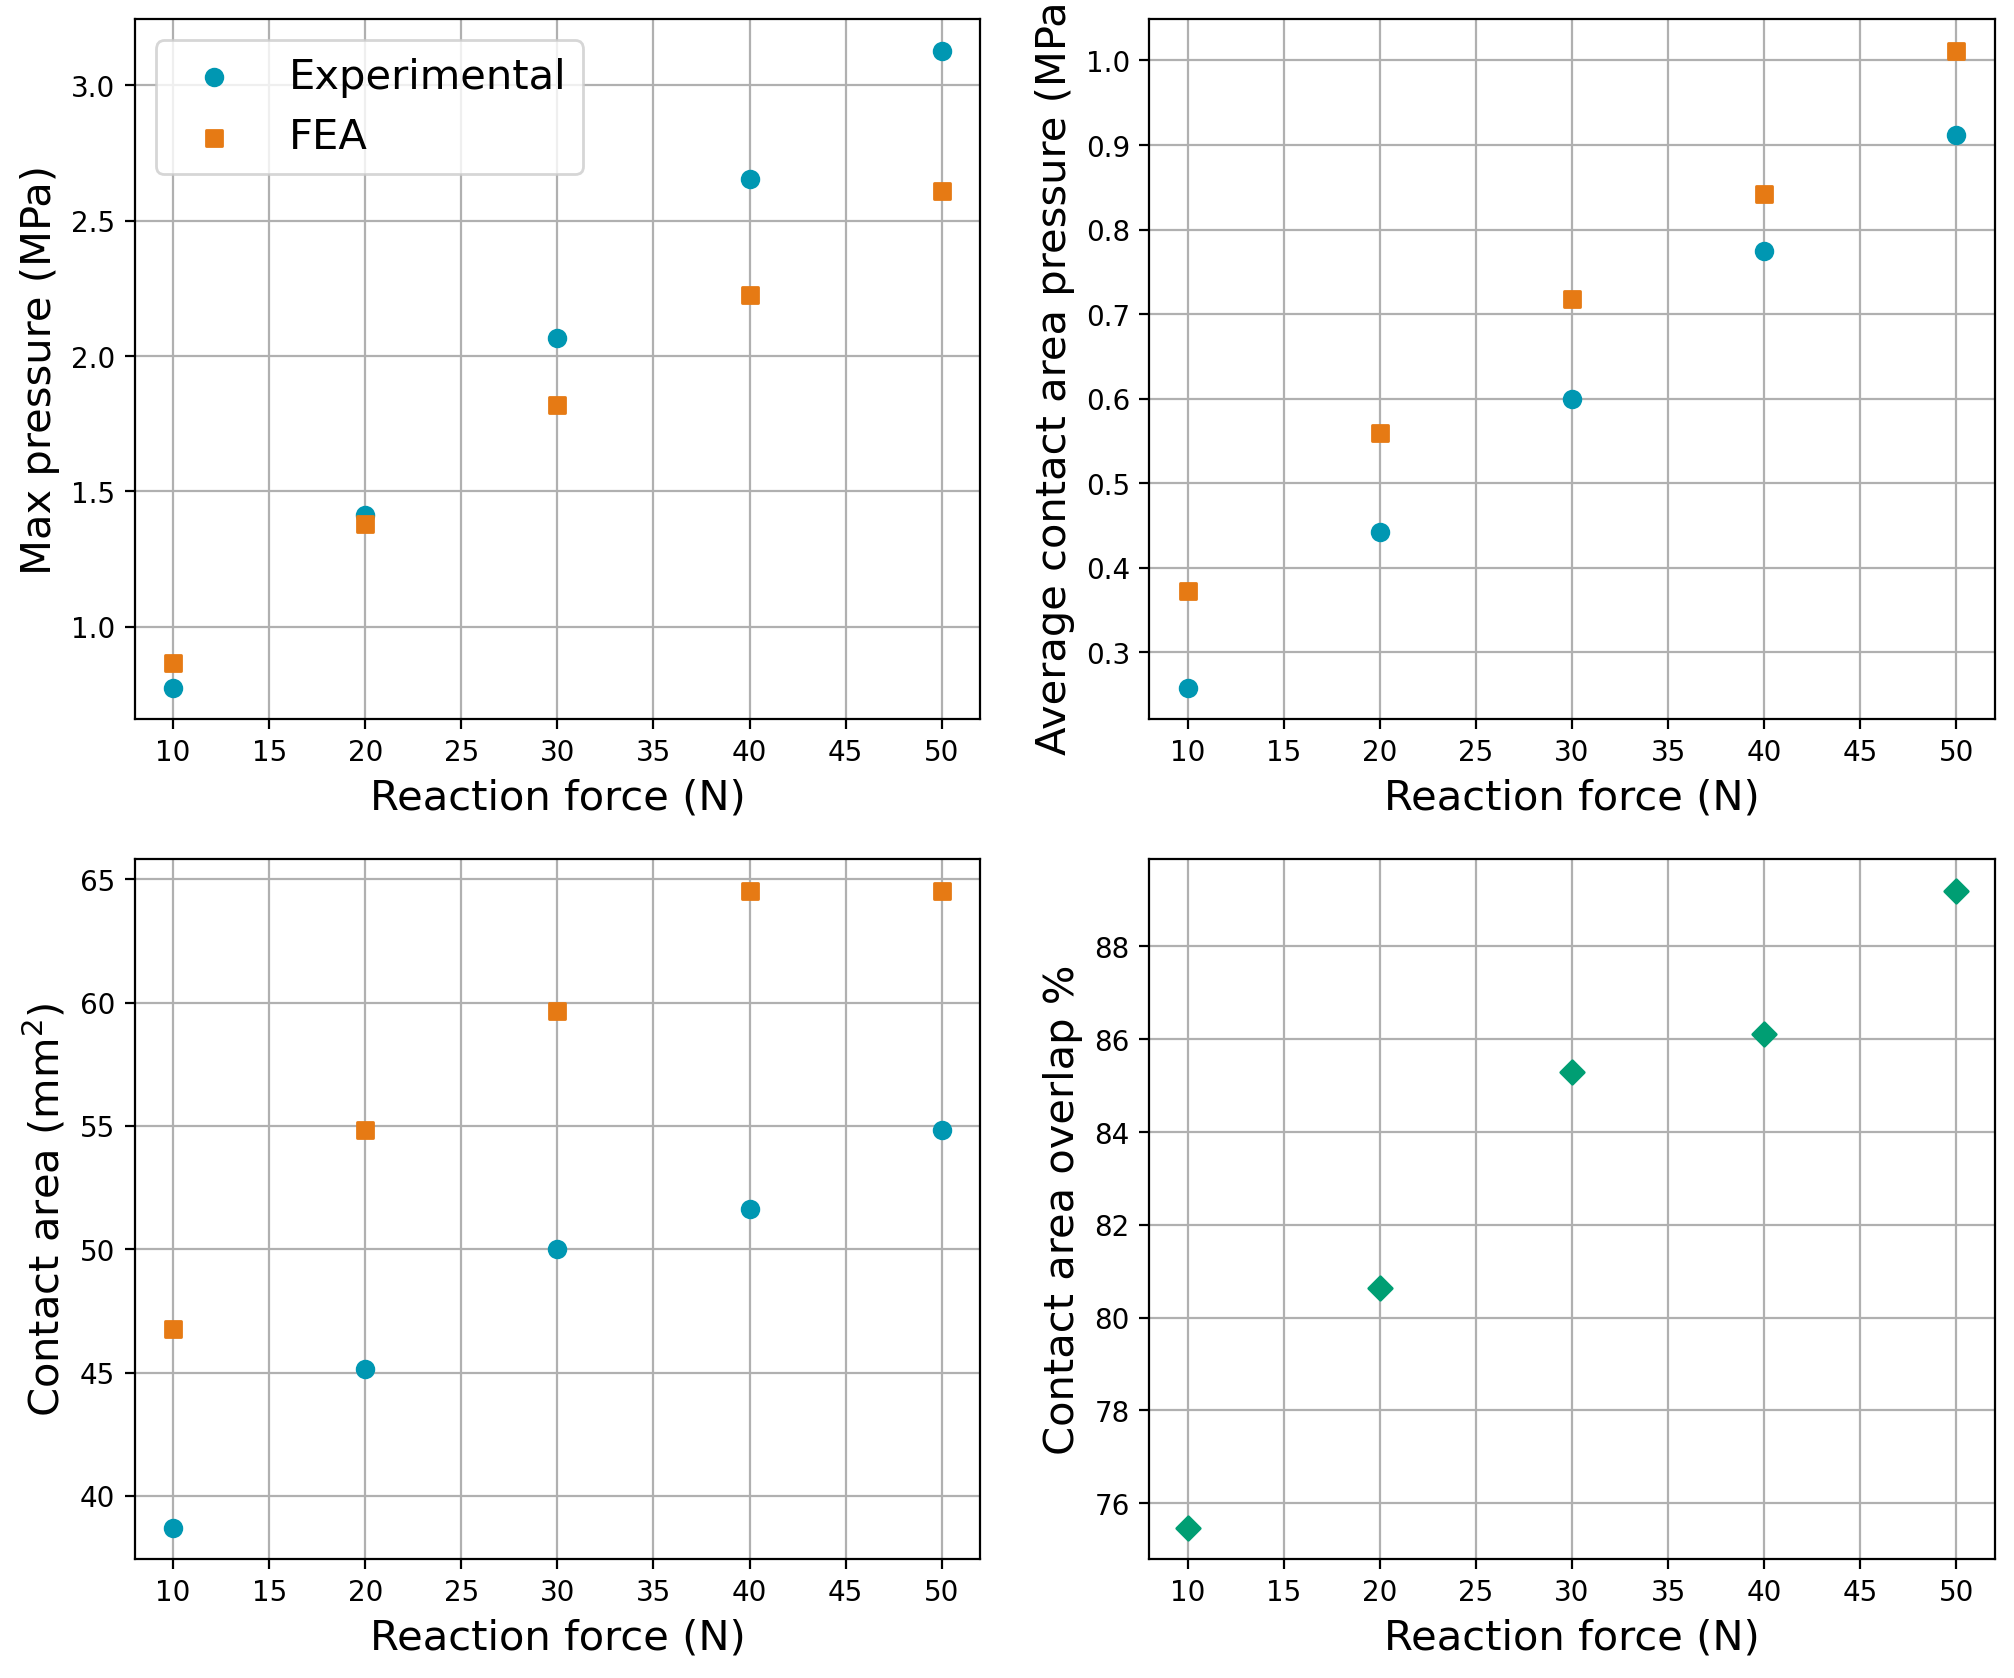

In [68]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 15
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fea": "#e67a14"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o",      # circle
    "fea": "s",    # square
}


Fs = sorted(tek_data.keys())
for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = compute_img_metrics(fea_grid_data[F])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FEA' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[0].scatter(F, fea_mets['P_max'], c=colors['fea'], marker=markers['fea'], label=label_fea, zorder=2)

    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['fea'], marker=markers['fea'], zorder=2)

    ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['fea'], marker=markers['fea'], zorder=2)

    ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker="D", zorder=2)


ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
plt.show()

#### I think the contact area for FEA is exagerated because the tekscan sensels don't border each other, there is empty gaps so fea cells should only be active if traingle is close enough to centre of sensor grid cell.
 - Should also influence which value/s used for the grid cells max and mean values, only values close enough to centre should be involved
 - Need to refine that in project sensor function


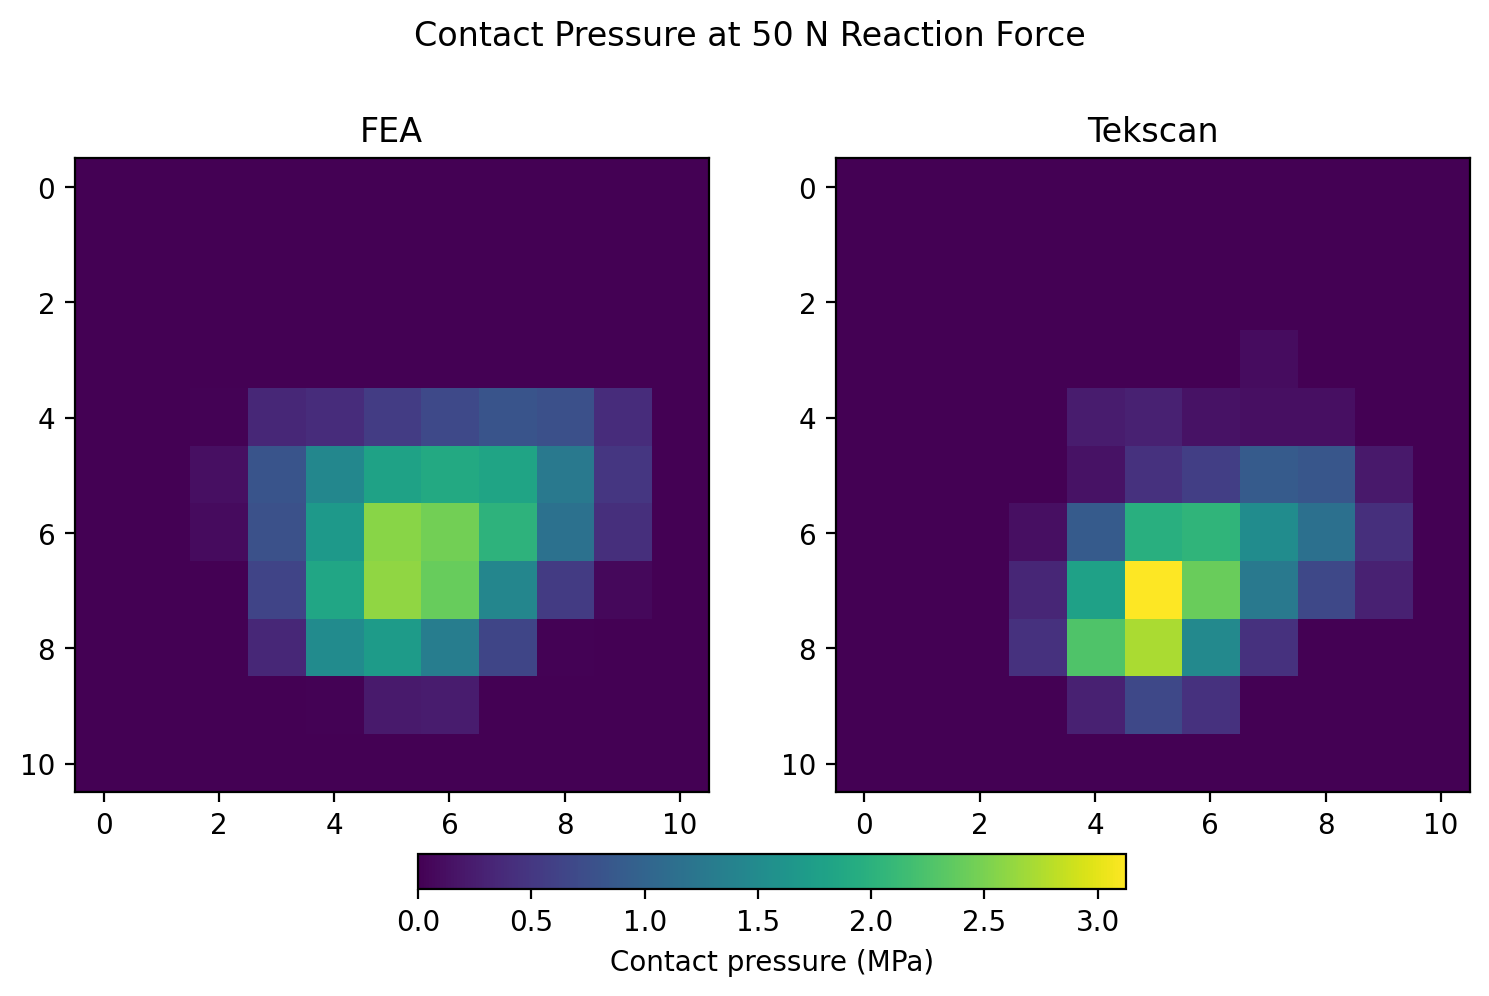

In [69]:
nrows, ncells = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[50], tek_data[50]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1])
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1])

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle('Contact Pressure at 50 N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

## FE downscaling options
 - original (above)
    - use PolyData.point_data_to_cell_data() to convert nodal CPRESS to face values
    - find cells whose cetres fall within each tekscan sensor cell
    - use mean of those values
- new
    - find nodes that fall within central active area of each tekscan grid cell
    - use mean of those values
- complex
    - use custom function to interpolate nodal CPRESS to faces
    - clip faces that intersect the central active area of each tekscan grid cell
    - integrate the pressures over the clipped areas
    - divide by the active area

In [61]:
bone = 'tpm'

Fs = sorted(fea_data.keys())

fea_grid_data_orig = {}
fea_grid_data_new = {}
fea_grid_data_complex = {}
for F in Fs:

    surf = fea_data[F]['tpm'].extract_surface(algorithm=None)
    mesh = surf.extract_cells(surf['tpm_CART_SURF']==1).extract_surface(algorithm=None)

    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-1, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)

    fea_grid_orig = project_sensor(mesh.extract_surface(algorithm=None), sensor, tek_data[F], data_loc='cells', 
                                downscale_fea=True, return_fea_grid=True, downscale_mode='mean')
    
    fea_grid_new = project_sensor_new(
        mesh=mesh,
        sensor=sensor,
        sensor_vals=tek_data[F],
        data_loc="cells",
        downscale_fea=True,
        return_fea_grid=True,
        active_sensel_width=0.635,  # use your model units
        pressure_name="CPRESS",
    )

    fea_grid_complex = project_sensor_complex(
        mesh=mesh,
        sensor=sensor,
        sensor_vals=tek_data[F],
        data_loc="cells",
        downscale_fea=True,
        return_fea_grid=True,
        active_sensel_width=0.635,  # mm, if your coordinates are mm
        pressure_name="CPRESS",
    )
    
    
    fea_grid_data_orig[F] = fea_grid_orig
    fea_grid_data_new[F] = fea_grid_new
    fea_grid_data_complex[F] = fea_grid_complex

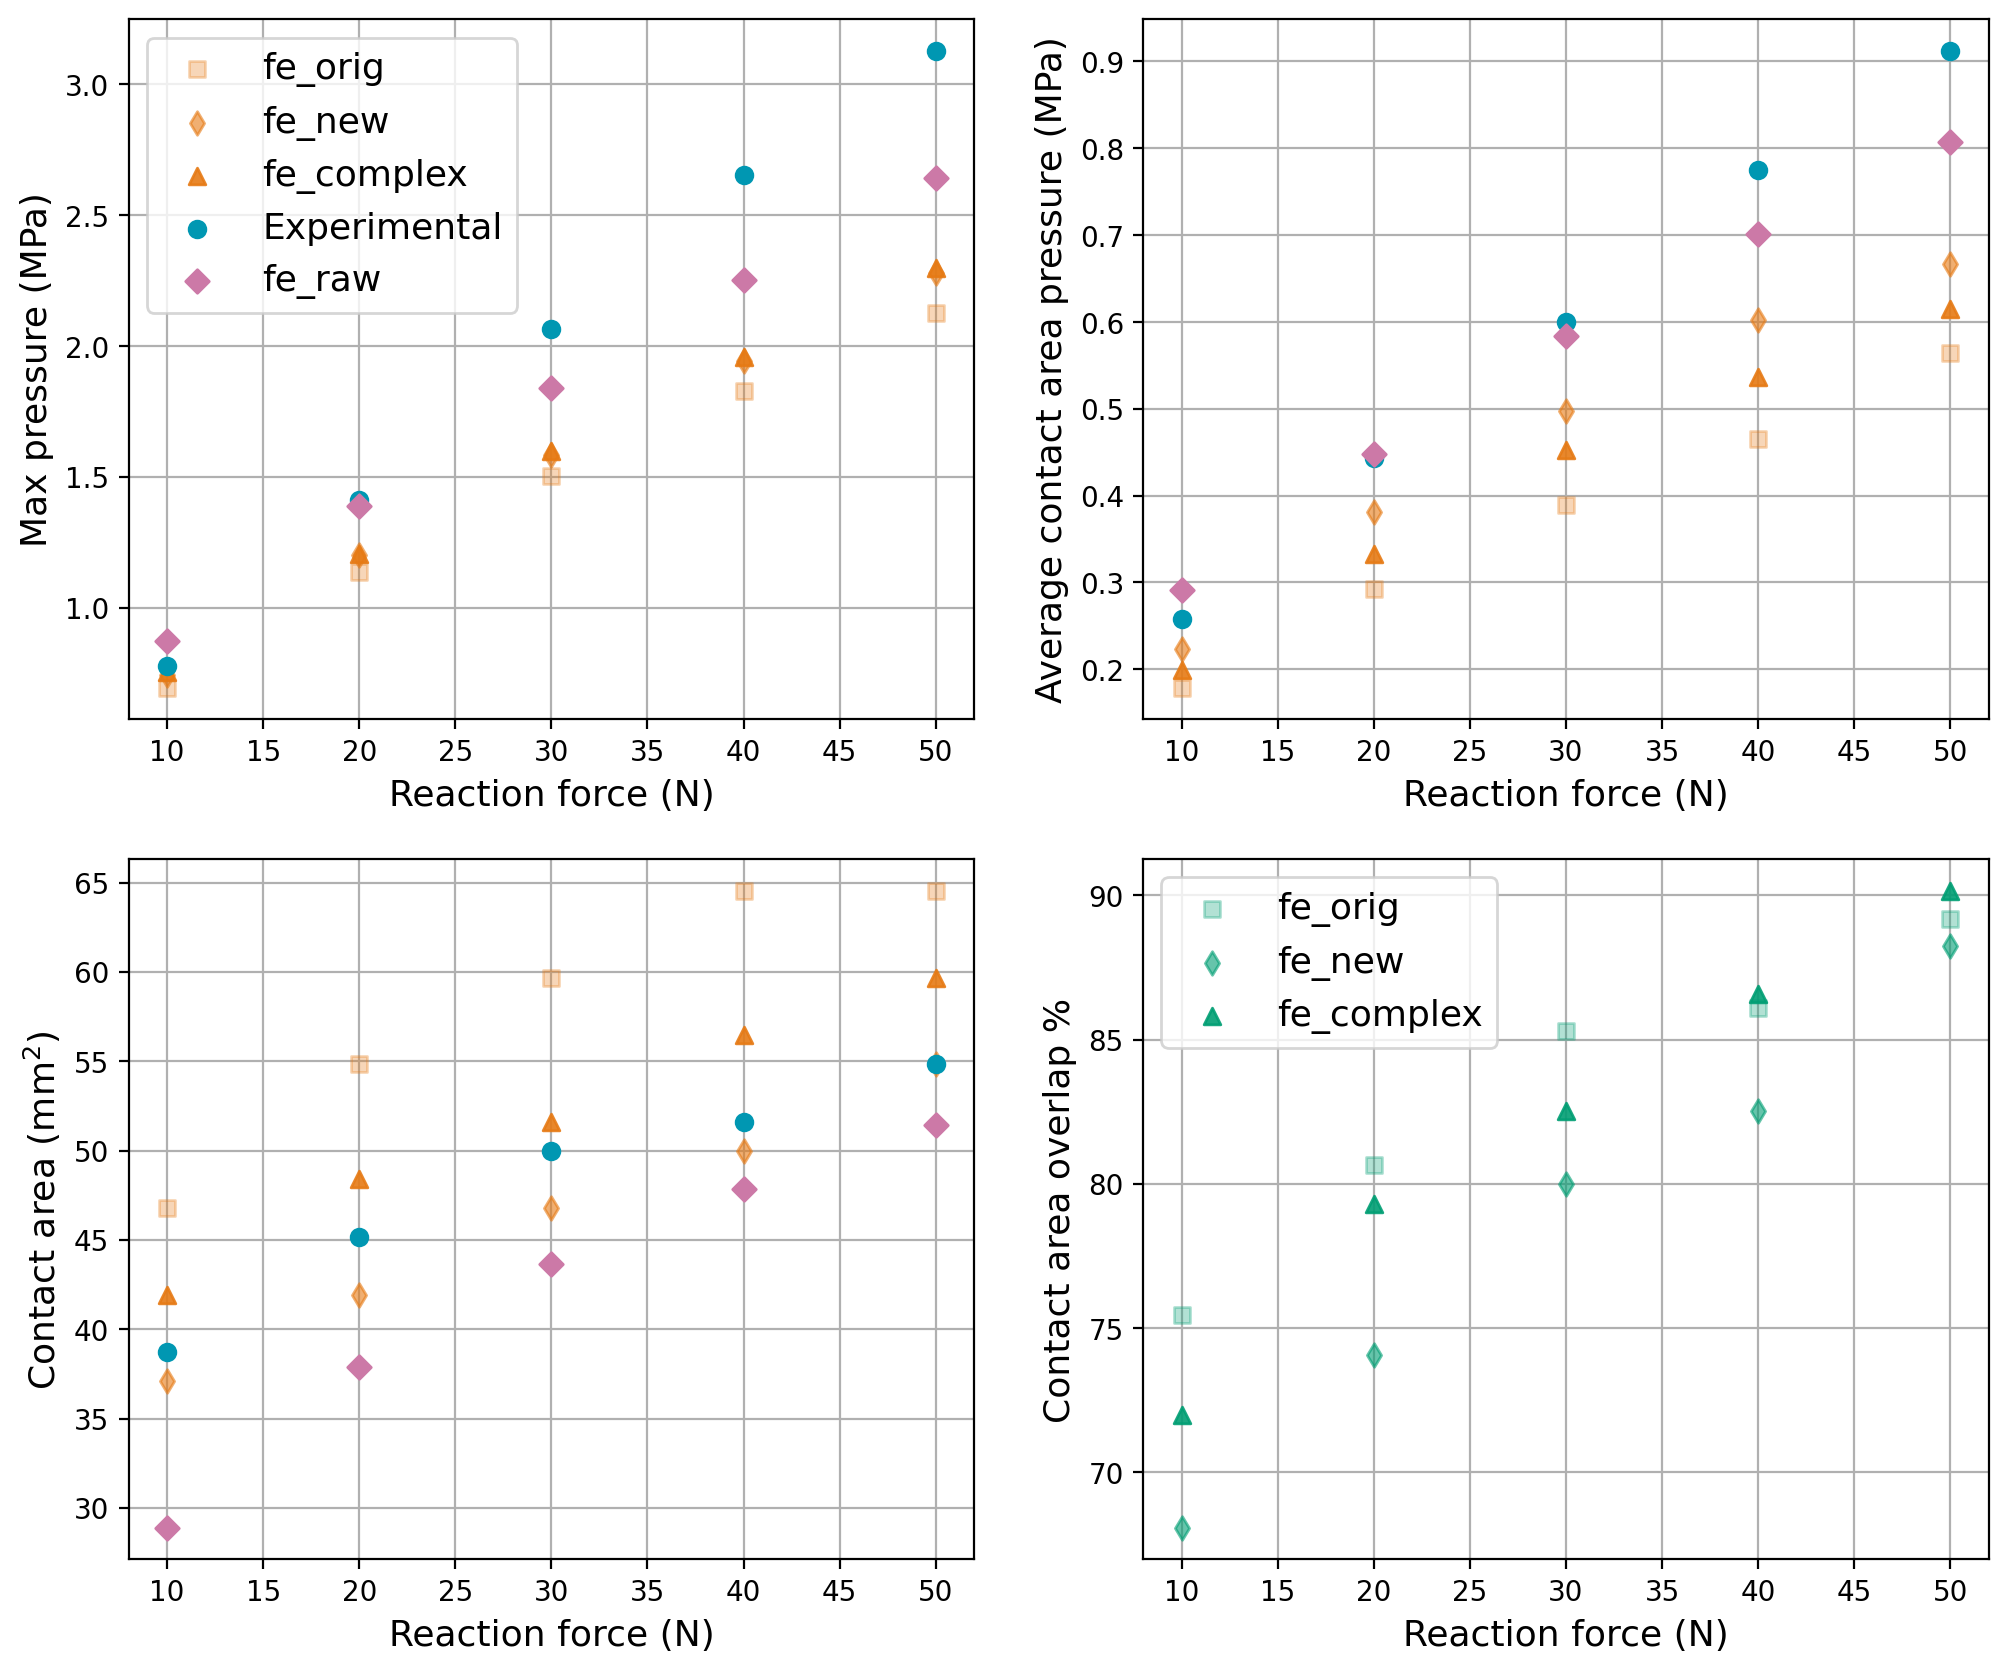

In [62]:
def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'],
        'P_max': mesh.field_data['P_max'],
        'P_avg': mesh.field_data['P_avg'],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fea": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o",      # circle
    "fe_orig": "s",    # square
    "fe_new": "d",    # diamond
    "fe_complex": "^",    # triangle
    'FE raw': "D"
}


Fs = sorted(tek_data.keys())
fea_labels = ['fe_orig', 'fe_new', 'fe_complex']
for i, fea_grid_data in enumerate([fea_grid_data_orig, fea_grid_data_new, fea_grid_data_complex]):
    for F in Fs:
        fea_mets = compute_img_metrics(fea_grid_data[F])
        tek_mets = compute_img_metrics(tek_data[F])

        a = (i+1) * 0.30
        label_fea = fea_labels[i] if F==10 else None
        ax[0].scatter(F, fea_mets['P_max'], c=colors['fea'], marker=markers[fea_labels[i]], label=label_fea, zorder=2, alpha=a)
        ax[1].scatter(F, fea_mets['P_avg'], c=colors['fea'], marker=markers[fea_labels[i]], zorder=2, alpha=a)
        ax[2].scatter(F, fea_mets['CA'], c=colors['fea'], marker=markers[fea_labels[i]], zorder=2, alpha=a)


        ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker=markers[fea_labels[i]], label=label_fea, zorder=2, alpha=a)

for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = fea_mets_from_mesh(fea_data[F]['tpm'])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'fe_raw' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)

    ax[0].scatter(F, fea_mets['P_max'], c=colors['fe_raw'], marker=markers['fe_raw'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['fe_raw'], marker=markers['fe_raw'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['fe_raw'], marker=markers['fe_raw'], zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
ax[3].legend(fontsize=fs)
plt.show()

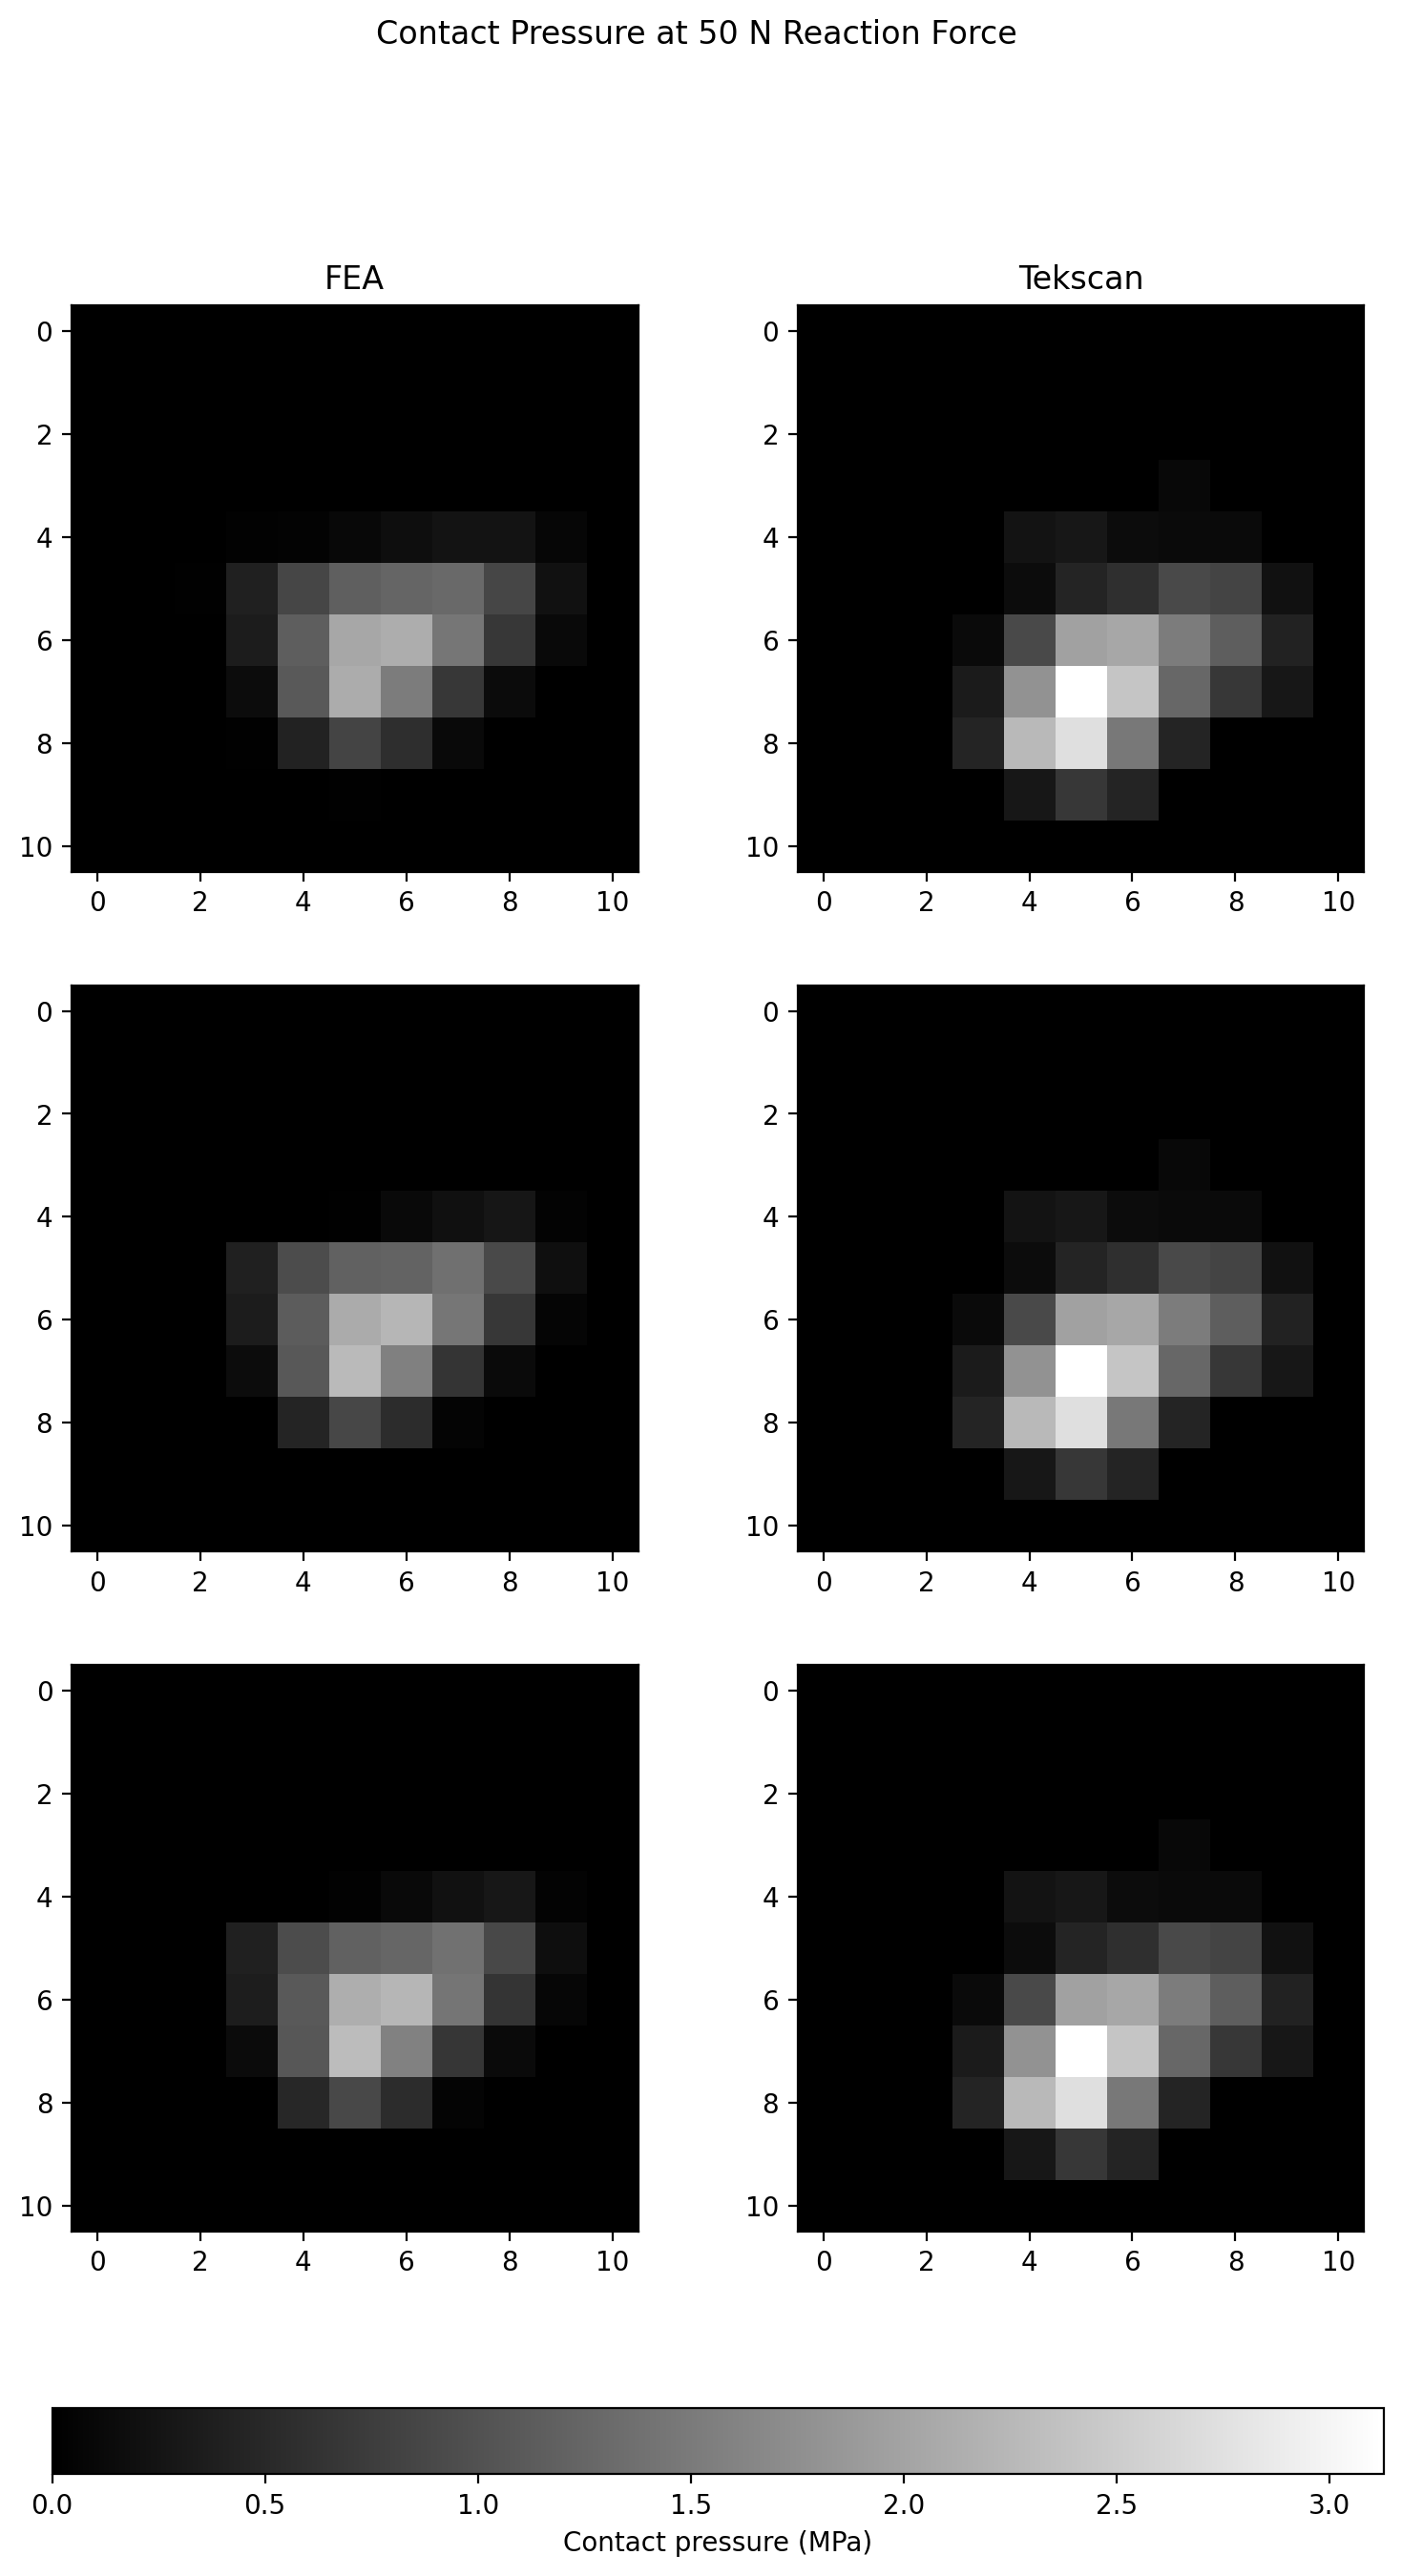

In [102]:
F = 50

nrows, ncells = 3, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_tek = tek_data[F]
clims = (0, np.max(P_tek))

for i, fea_grid_data in enumerate([fea_grid_data_orig, fea_grid_data_new, fea_grid_data_complex]):
    P_fea = fea_grid_data[F]

    im = ax[i, 0].imshow(P_fea, vmin=clims[0], vmax=clims[1], cmap='gray')
    ax[i, 1].imshow(P_tek, vmin=clims[0], vmax=clims[1], cmap='gray')

ax[0, 0].set_title('FEA')
ax[0, 1].set_title('Tekscan')
fig.suptitle('Contact Pressure at 50 N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

# Compare clean
 - CA overlap error bars are tricky cos it requires a lot of assumptions about the shapes of the small and large area possibilities
 - For pressure, need calibration to help estimate error
 - Also possible to just use SD of repeats for error bars

In [103]:
bone = 'tpm'

Fs = sorted(fea_data.keys())
fea_grid_data = {}
for F in Fs:

    surf = fea_data[F]['tpm'].extract_surface(algorithm=None)
    mesh = surf.extract_cells(surf['tpm_CART_SURF']==1).extract_surface(algorithm=None)

    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-1, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)
    
    fea_grid_new = project_sensor_new(
        mesh=mesh,
        sensor=sensor,
        sensor_vals=tek_data[F],
        data_loc="cells",
        downscale_fea=True,
        return_fea_grid=True,
        active_sensel_width=0.635,  # use your model units
        pressure_name="CPRESS",
    )
    
    
    fea_grid_data[F] = fea_grid_new

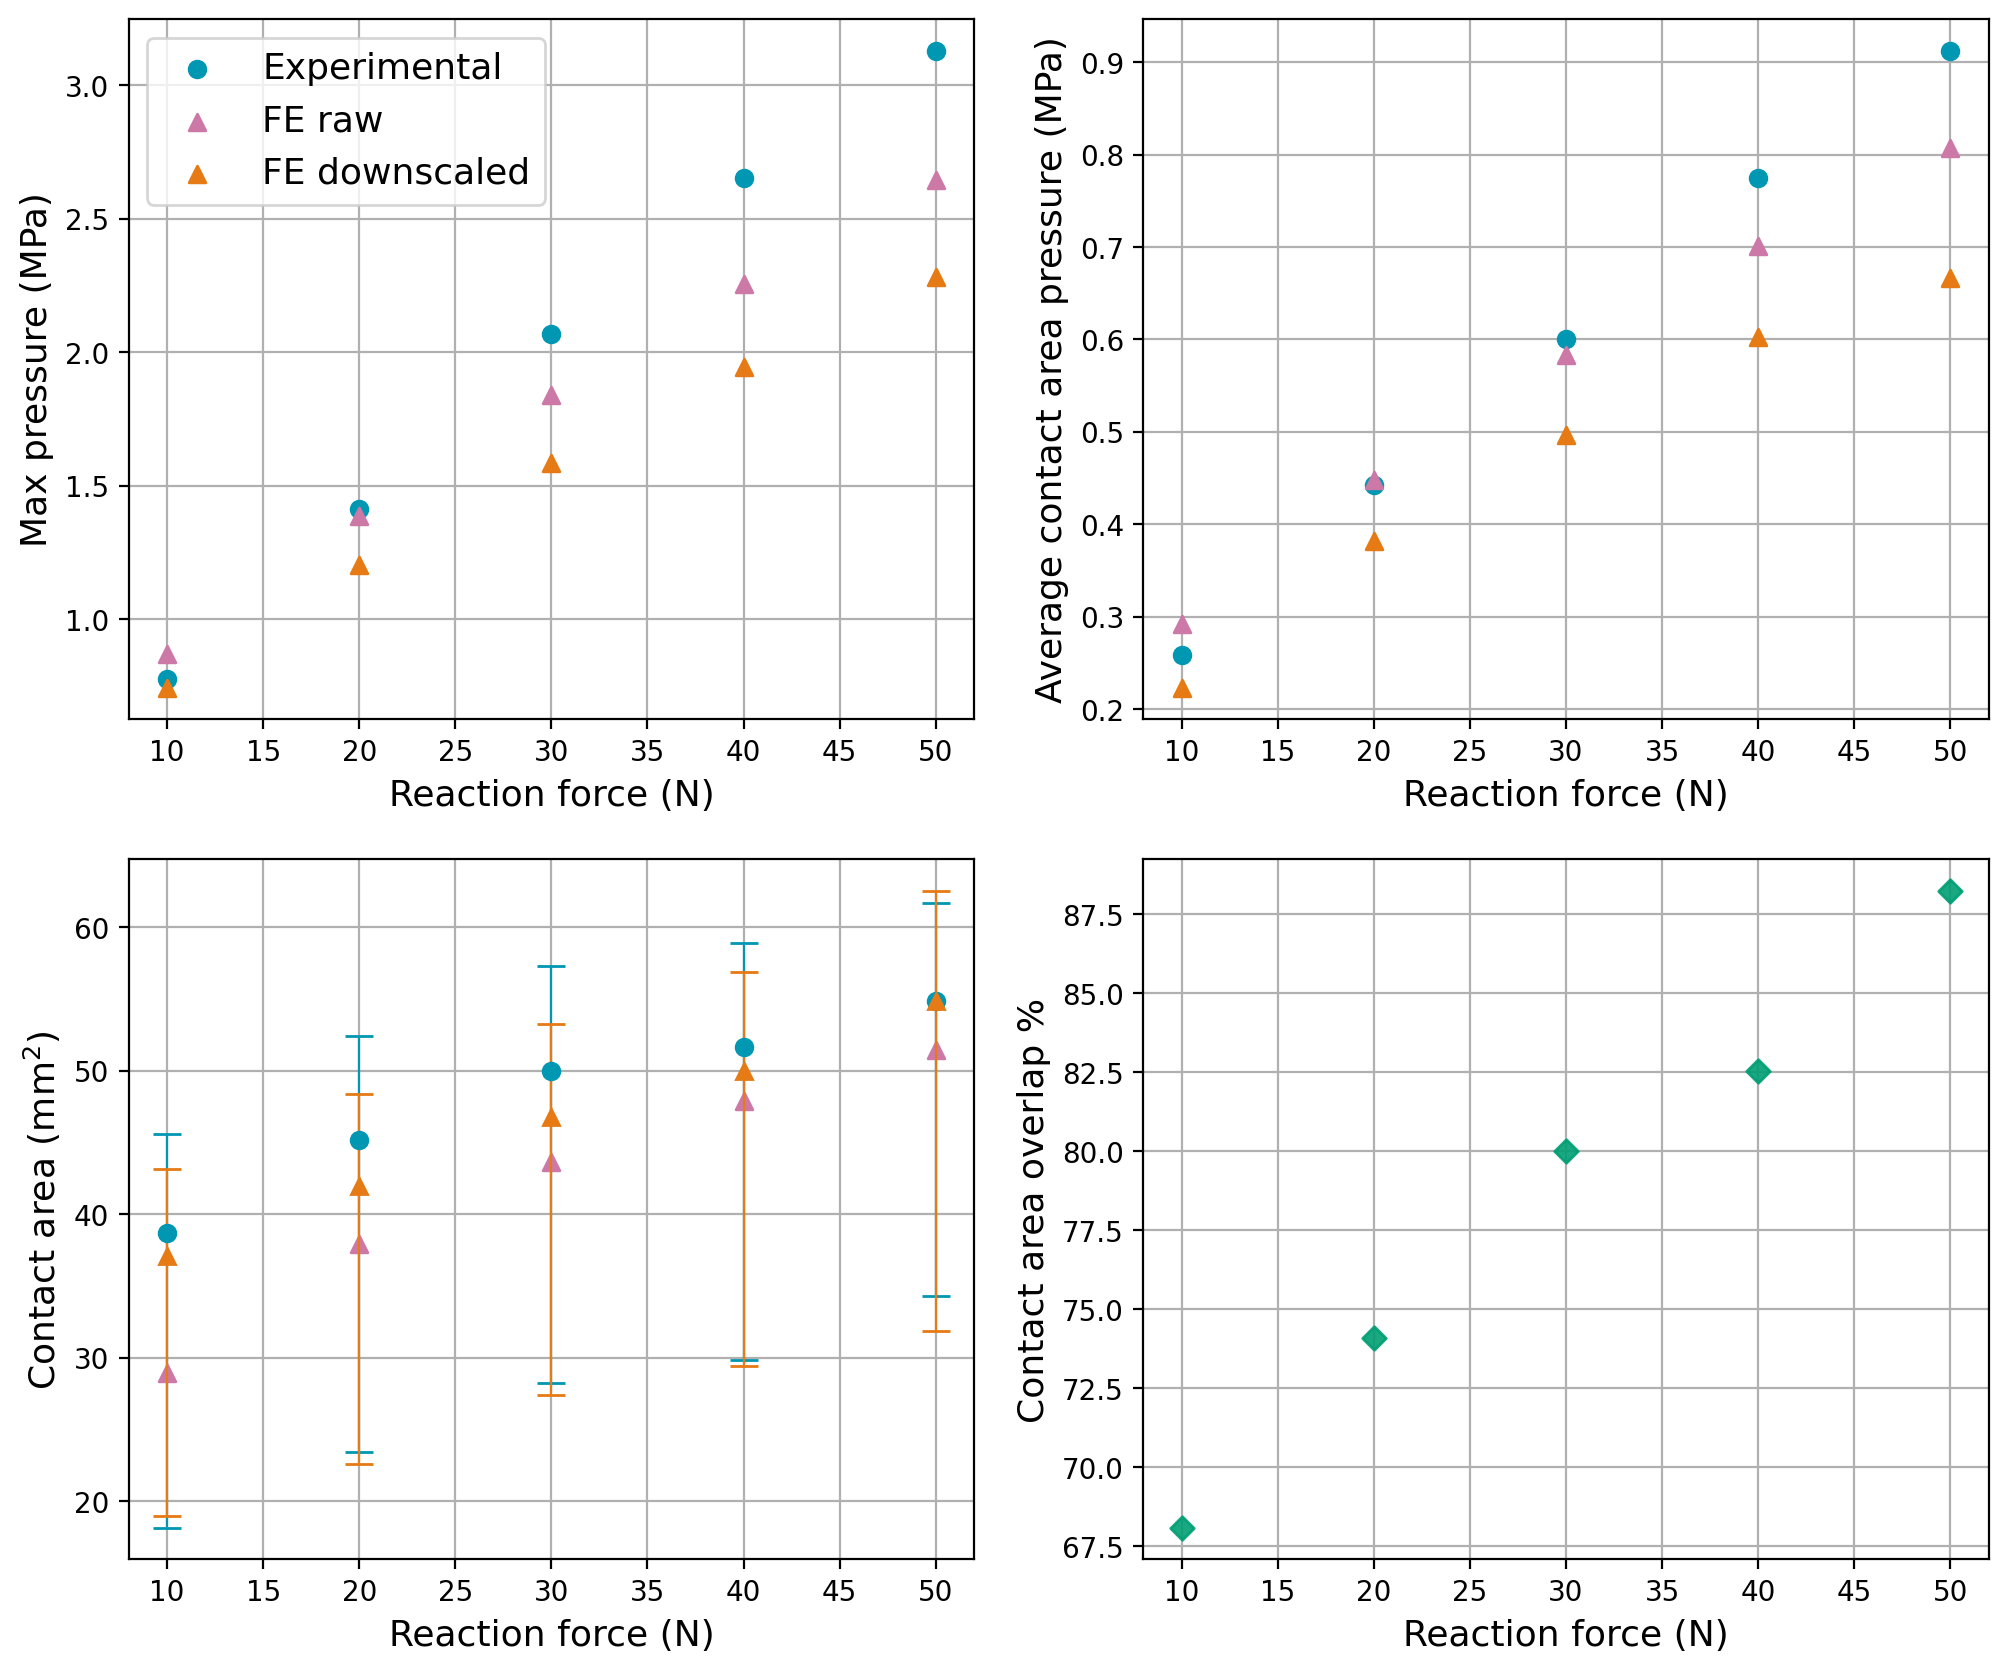

In [123]:
def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'][0],
        'P_max': mesh.field_data['P_max'][0],
        'P_avg': mesh.field_data['P_avg'][0],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "FE downscaled": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}


Fs = sorted(tek_data.keys())

for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = fea_mets_from_mesh(fea_data[F]['tpm'])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FE raw' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    #ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE raw'], marker=markers['FE raw'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)

for F in Fs:
    fea_mets = compute_img_metrics(fea_grid_data[F])
    tek_mets = compute_img_metrics(tek_data[F])

    label_fea = 'FE downscaled' if F==10 else None
    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE downscaled'], marker=markers['FE downscaled'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    #ax[2].scatter(F, fea_mets['CA'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    ax[2].errorbar(F, fea_mets['CA'], yerr=[[fea_mets['CA_e_low']],[fea_mets['CA_e_high']]],c=colors['FE downscaled'],marker=markers['FE downscaled'],capsize=5,elinewidth=0.8)


    ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker="D", label=label_fea, zorder=2, alpha=a)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

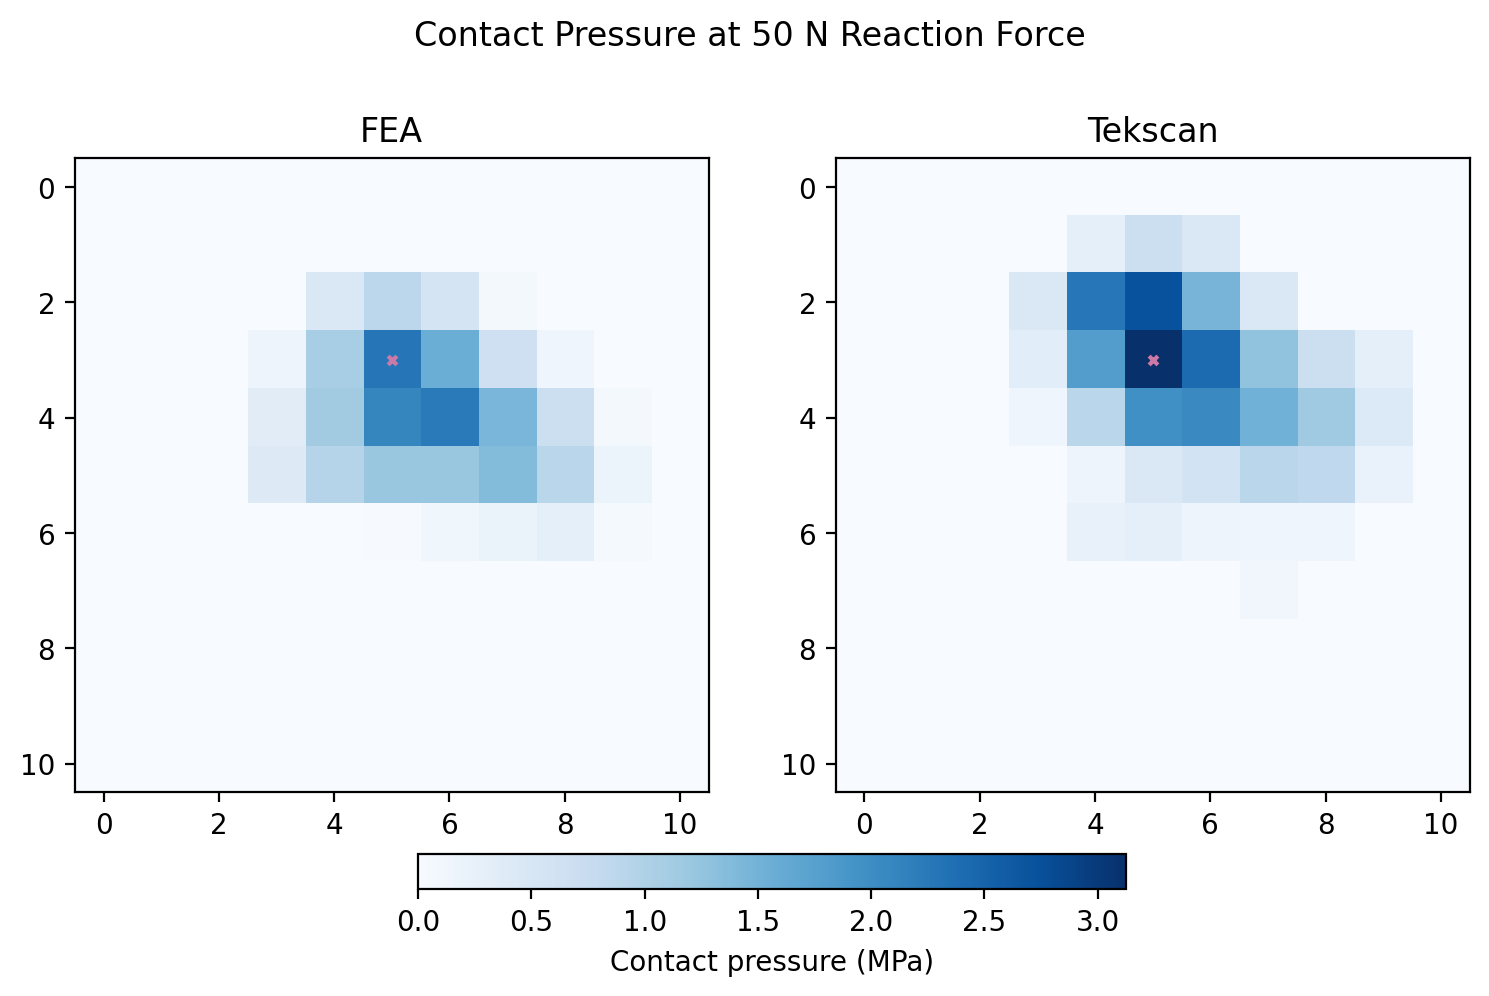

In [151]:
F = 50

nrows, ncells = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[F][::-1], tek_data[F][::-1]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1], cmap="Blues")
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1], cmap='Blues')

# peak pressure loc
y, x = compute_img_metrics(P_fea)['loc_Pmax']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(P_tek)['loc_Pmax']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

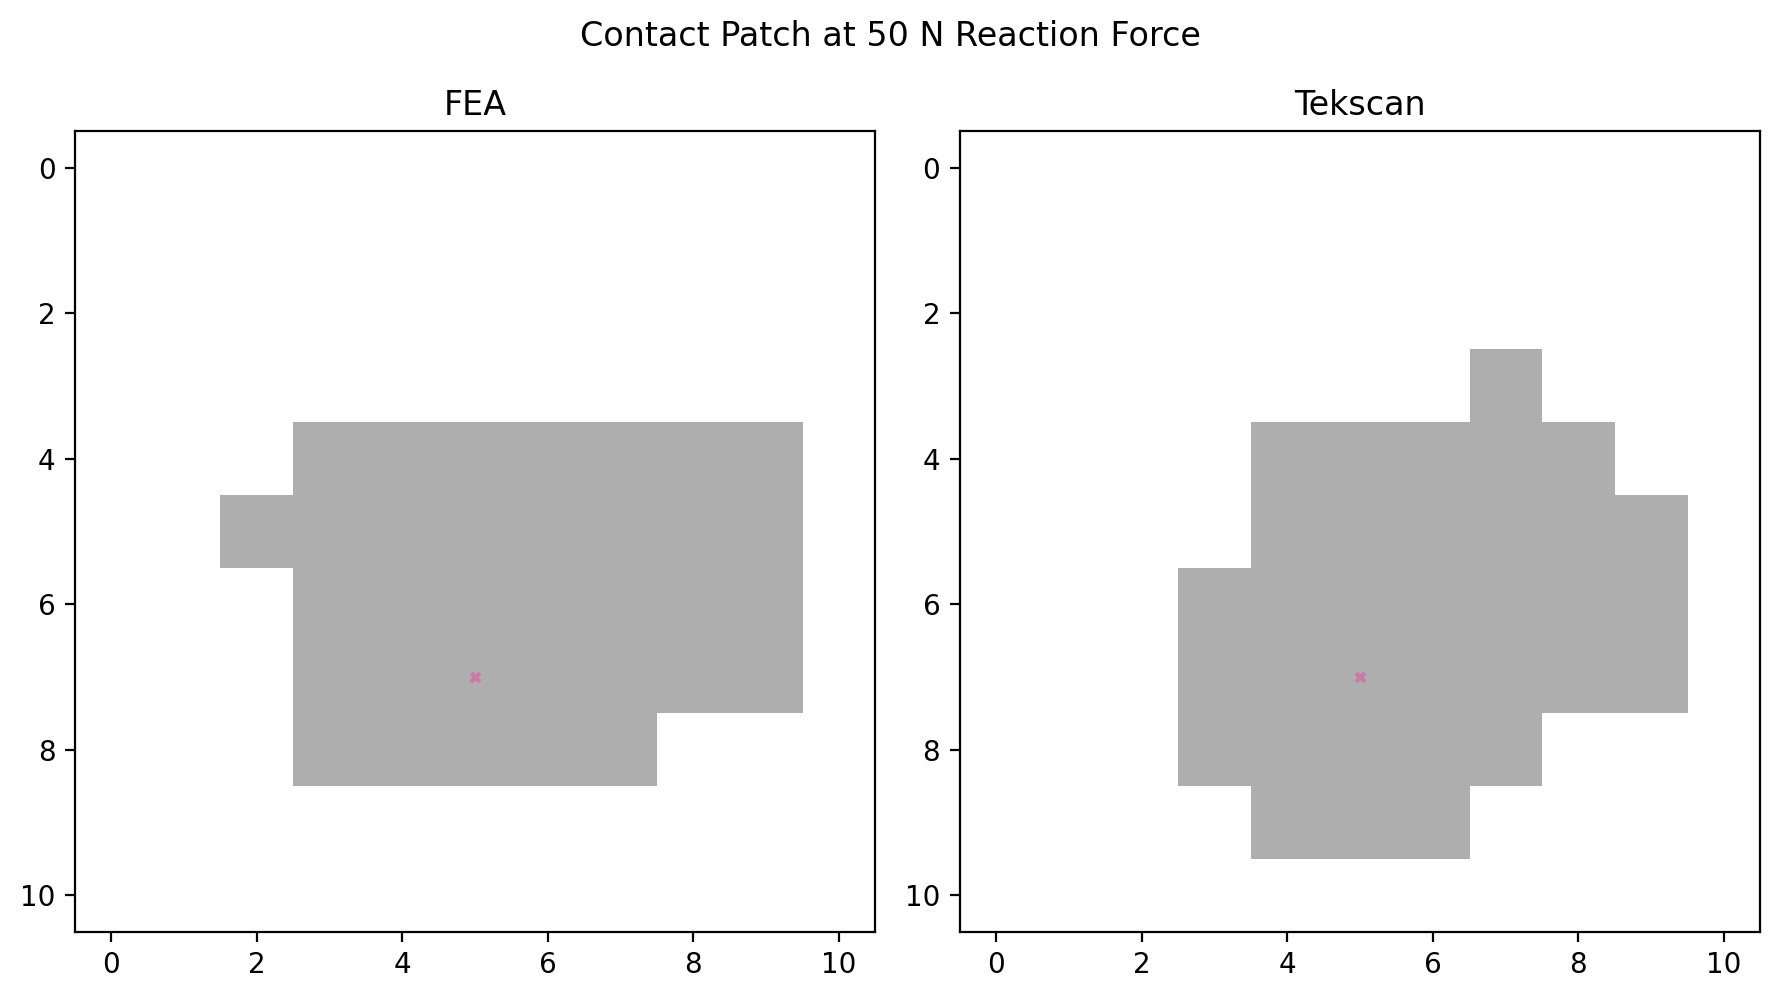

In [114]:
nrows, ncells = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[F], tek_data[F]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea>0, vmin=clims[0], vmax=clims[1], cmap='gray_r')
ax[1].imshow(P_tek>0, vmin=clims[0], vmax=clims[1], cmap='gray_r')

# peak pressure loc
y, x = compute_img_metrics(fea_grid_data[F])['loc_Pmax']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(tek_data[F])['loc_Pmax']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Patch at {F} N Reaction Force')

plt.tight_layout()
plt.show()

In [127]:
surf = fea_data[50]['tpm'].extract_surface(algorithm=None)
mesh = surf.extract_cells(surf['tpm_CART_SURF']==1).extract_surface(algorithm=None)

sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-1, sensor_size=13.97) # skinny guide ledge
sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)

fea_grid_new = project_sensor_new(
    mesh=mesh,
    sensor=sensor,
    sensor_vals=tek_data[F],
    data_loc="cells",
    downscale_fea=True,
    return_fea_grid=True,
    active_sensel_width=0.635,  # use your model units
    pressure_name="CPRESS",
)

In [147]:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars='tek_press', cmap='Blues', clim=clims, show_scalar_bar=False)
pl.add_mesh(surf.extract_cells(surf['tpm_CART_SURF']==1, invert=True), color='gray')
pl.camera_position = pv.CameraPosition(position=(5.879025791655938, 0.2872888246671539, 1.8132017160002993),
               focal_point=(-25.316126142602513, 0.41016595490700397, 4.860909511910631),
               viewup=(0.09540167880159987, 0.23638849511060628, 0.9669638044214371))
pl.show()

Widget(value='<iframe src="http://localhost:61786/index.html?ui=P_0x33e04f170_17&reconnect=auto" class="pyvist…

In [146]:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars='CPRESS', cmap='Blues', clim=clims, show_scalar_bar=False)
pl.add_mesh(surf.extract_cells(surf['tpm_CART_SURF']==1, invert=True), color='gray')
pl.camera_position = pv.CameraPosition(position=(5.879025791655938, 0.2872888246671539, 1.8132017160002993),
               focal_point=(-25.316126142602513, 0.41016595490700397, 4.860909511910631),
               viewup=(0.09540167880159987, 0.23638849511060628, 0.9669638044214371))
pl.show()

Widget(value='<iframe src="http://localhost:61786/index.html?ui=P_0x3617fb770_16&reconnect=auto" class="pyvist…